# SPRINT 10. Analítica de datos en Pandas

## Descripción
En esta tarea te enfrentarás a un ejercicio de limpieza y analítica de datos.

Tenemos un dataset proveniente de una encuesta a nuestros trabajadores y trabajadores, y debemos garantizar que los datos se procesan correctamente, tanto en formato como en legibilidad.

## Nivel 1

In [26]:
import pandas as pd # manipulación y análisis de datos con DataFrames

from pandas.api.types import (
    is_numeric_dtype,          # detectar columnas numéricas
    is_datetime64_any_dtype,   # detectar columnas de tipo fecha
    is_categorical_dtype       # detectar columnas categóricas
)

import numpy as np # operaciones numéricas y valores nulos (np.nan)

import seaborn as sns # visualización y datasets de ejemplo

import datetime as dt # fechas (actual, edades)

import matplotlib # librería base de visualización

import matplotlib.pyplot as plt # crear y guardar los gráficos

import os # gestión de carpetas y rutas de archivos

### 1.
* Importa como un DataFrame el archivo sprint10.xlsx. Asegúrate de que el archivo se importa correctamente, con los nombres de columnas que le corresponden, sin manipular el archivo original.

> pd.read_excel() - función de Pandas para leer archivos de Excel y convertirlos en un DataFrame

> header=3 - indica que la fila 4 del Excel contiene los nombres de las columnas

> index_col=0 - selecciona la primera columna del Excel como índice del DataFrame. Si se omite, Pandas genera un índice numérico empezando desde cero, lo que causaría que la columna de índice original del Excel se duplique, porque habría dos columnas iguales

In [27]:
df = pd.read_excel('sprint10.xlsx', header=3, index_col=0)

df

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
0,Inês,Ferreira Silva,16928694K,Portugal,Lisboa,25,2,1953,D,1.144 €,NaN,1.0,Grup B
1,Clara,Sánchez Martínez,27724652S,Espanya,Barcelona,18,3,1996,D,1.253 €,1.0,NaN,Grup A
2,Fatima,Fassi,38141675A,Marroc,Rabat,6,11,2005,A,1.441 €,1.0,NaN,Grup A
3,Khadija,Bennani Bennani,59157262R,Marroc,Rabat,20,1,1995,D,1.944 €,NaN,1.0,Grup B
4,Toni,Sánchez García,69630528M,Espanya,Barcelona,9,8,1999,H,1.043 €,NaN,1.0,Grup A
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Marta,Ferrer Ferrer,25161375F,Espanya,Sevilla,1,6,1951,D,1.216 €,NaN,1.0,Grup B
996,Joan,García,52145541P,Espanya,Sevilla,11,4,1959,H,971 €,NaN,1.0,Grup A
997,Laia,Ferrer Martínez,69760120X,Espanya,Barcelona,11,11,1980,D,682 €,NaN,1.0,Grup A
998,Jordi,García,82947791W,Espanya,Barcelona,23,5,1984,H,1.699 €,1.0,NaN,Grup C


* Ordena el DataFrame por el país de origen. En caso de empate, ordena por el nombre de la ciudad.
* Muestra las primeras 10 filas.

> sort_values() - ordena el DataFrame según los valores de una o varias columnas

> head() - devuelve las primeras n filas del DataFrame. Sin parámetros, por defecto muestra las primeras 5 filas

> display() - muestra el DataFrame de manera más visual y “bonita” mantiene el formato de tabla

In [28]:
df_ordenado = df.sort_values(["País d'origen", 'Ciutat'])
primeras_10=df_ordenado.head(10)
print("Las primeras 10 filas son:")
display(primeras_10)

Las primeras 10 filas son:


,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
21,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A
154,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B
224,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.0,Grup B
278,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,D,1.557 €,1.0,NaN,Grup B
602,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,H,2.754 €,1.0,NaN,Grup D
871,Lea,Fischer,14773153R,Alemanya,Berlín,9,9,1986,D,1.370 €,1.0,NaN,Grup A
281,Lea,Müller,23266650S,Alemanya,Hamburg,14,4,2003,D,1.314 €,NaN,1.0,Grup A
435,Anna,Müller,83274277X,Alemanya,Hamburg,1,1,1987,D,2.464 €,NaN,1.0,Grup C
444,Laura,Schmidt Müller,60161784X,Alemanya,Hamburg,15,6,1987,NC,2.035 €,1.0,NaN,Grup C
487,Lukas,Müller Fischer,60982309S,Alemanya,Hamburg,28,3,1971,H,2.042 €,NaN,1.0,Grup B


Adicionalmente, realiza un print donde compruebe que el DNI sólo tiene valores únicos.

> is_unique es un atributo de una Serie de Pandas, devuelve True si todos los valores de la columna son únicos

> describe() es un método de Pandas que devuelve estadísticas descriptivas, para columnas no numéricas devuelve:

> •	count: número de valores no nulos

> •	unique: número de valores distintos

> Si "count" y "unique" coinciden, significa que todos los DNI son únicos

In [29]:
if df_ordenado['DNI'].is_unique:
    print("Todos los DNI son únicos.")
else:
    print("Existen DNI duplicados.")
    
recuento_dni=df_ordenado['DNI'].describe()
print(recuento_dni)

Todos los DNI son únicos.
count          1000
unique         1000
top       28973553Z
freq              1
Name: DNI, dtype: object


### 2.
* Crea una columna que sea el nombre completo.

> df_ordenado['Nom Complet'] = crea una nueva columna llamada 'Nom Complet' y guarda el resultado de la concatenación

> "+"  concatena cadenas en Python

> ' ' un espacio para separar el nombre de los apellidos

In [30]:
df_ordenado['Nom Complet'] = df_ordenado['Nom'] + ' ' + df_ordenado['Cognoms']

* Crea una columna si la persona ha nacido en España o no.

> df_ordenado['Nascut/da a Espanya'] = [...] - crea una nueva columna con la lista generada 

> 'Sí' if x == 'Espanya' else 'No' - expresión condicional

> for x in df_ordenado['País d\'origen'] - recorre cada valor de la columna 

In [31]:
df_ordenado['Nascut/da a Espanya']=['Sí' if x == 'Espanya' else 'No'for x in df_ordenado['País d\'origen']]

* Pone el DNI como índice del DataFrame (nombres de filas).

> set_index('DNI') - cambia el índice del DataFrame al DNI

> inplace=True - hace el cambio directamente en el DataFrame

In [32]:
df_ordenado.set_index('DNI', inplace=True)

* Sustituye el nombre de las columnas Día de Nacimiento, Mes de Nacimiento y Año de Nacimiento por Día, Mes y Año.

> rename(columns={...}) - renombra columnas según el diccionario:

> •	clave - nombre antiguo

> •	valor - nuevo nombre

In [33]:
df_ordenado = df_ordenado.rename(columns={'Dia de Naixement':'Dia', 'Mes de Naixement': 'Mes', 'Any de Naixement':'Any'})

* Sustituye a H - Home, D - Dona, A - Altres y NC por un dato faltante (nan/null/na).

Muestra todos los cambios que has realizado en una sola tabla.

> .map({...}) - reemplaza cada valor según el diccionario

> np.nan - Not a Number, un valor especial que representa “dato faltante” o “valor desconocido”

In [34]:
df_ordenado['Gènere'] = df_ordenado['Gènere'].map({
    'H': 'Home',
    'D': 'Dona',
    'A': 'Altres',
    'NC': np.nan})
df_ordenado

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nom Complet,Nascut/da a Espanya
DNI,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,NaN,1.0,Grup A,Mia Schneider Fischer,No
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,1.0,NaN,Grup B,Laura Schneider Fischer,No
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2.013 €,NaN,1.0,Grup B,Lea Schneider Schneider,No
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1.557 €,1.0,NaN,Grup B,Mia Fischer,No
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2.754 €,1.0,NaN,Grup D,Jonas Schneider,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2.033 €,NaN,1.0,Grup B,Emily Taylor Jones,No
57441590Y,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1.130 €,1.0,NaN,Grup A,George Brown Jones,No
58204038A,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1.023 €,NaN,1.0,Grup A,Olivia Brown Brown,No


### 3.
Junta las columnas Hijos y No Hijos en una sola columna, utilizando el método .apply() y definiendo una función que resuelva el problema. La columna nueva debe llamarse "Hijos" y tomar los valores "Sí" o "No".

> def hijos(fila) - se define una función que, a partir de los valores de las columnas 'Fills' y 'No Fills' de cada fila, determina si la persona tiene hijos o no

> apply(hijos, axis=1) - se aplica la función "hijos" fila a fila  

> drop(columns='No Fills') - se elimina la columna 'No Fills', ya que la información queda correctamente integrada en la columna 'Fills'

In [35]:
def hijos(fila):
    if fila['Fills'] == 1:
        return 'Sí'
    elif fila['No Fills'] == 1:
        return 'No'
    else:
        return None

df_ordenado['Fills'] = df_ordenado.apply(hijos, axis=1)
df_ordenado = df_ordenado.drop(columns='No Fills')

df_ordenado

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional,Nom Complet,Nascut/da a Espanya
DNI,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,No,Grup A,Mia Schneider Fischer,No
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,Sí,Grup B,Laura Schneider Fischer,No
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2.013 €,No,Grup B,Lea Schneider Schneider,No
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1.557 €,Sí,Grup B,Mia Fischer,No
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2.754 €,Sí,Grup D,Jonas Schneider,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2.033 €,No,Grup B,Emily Taylor Jones,No
57441590Y,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1.130 €,Sí,Grup A,George Brown Jones,No
58204038A,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1.023 €,No,Grup A,Olivia Brown Brown,No


### 4.
* Crea una tabla resumen que permita ver el sueldo medio, mediano, mínimo y máximo por Género.

* Ordena la tabla en función del sueldo medio.

In [36]:
df_ordenado['Salari mensual'].describe()

count        1000
unique        767
top       1.672 €
freq            4
Name: Salari mensual, dtype: object

> La columna no es numérica, tiene tipo object. Esto ocurre porque los valores contienen símbolo € y separador de miles

> Antes de poder calcular medias o medianas, es necesario limpiar y convertir la columna

> He optado por eliminar todos los caracteres que no son dígitos (r'[^\d]') antes de convertir el salario a tipo float, porque en el dataset actual no hay céntimos ni decimales, solo separador de miles y símbolo de euro

> Se utiliza regex=True para indicar que el patrón proporcionado es una expresión regular. En este caso, [^\d] representa cualquier carácter que no sea un dígito y conservar únicamente los números 

> Esta estrategia asegura que los valores se interpretan correctamente como números enteros (por ejemplo, 1.769 € → 1769) y evita errores de conversión

> Si hubiera decimales (céntimos), habría que tratarlos de manera distinta para no alterar el valor real. Por ejemplo, eliminar todos los símbolos en 2.000,50 € sin cuidado convertiría el valor a 200050, que sería totalmente incorrecto

> groupby() - agrupa las filas por género

> .agg([...]) - aplica varias funciones de agregación a la vez

> .sort_values(by='mean') - ordena la tabla en función del sueldo medio

In [37]:
df_ordenado['Salari mensual'] = df_ordenado['Salari mensual'].replace(r'[^\d]', '', regex=True).astype(float)

df_sueldo_genero = df_ordenado.groupby('Gènere')['Salari mensual'].agg(['mean','median','min','max'])

df_sueldo_genero = df_sueldo_genero.sort_values(by='mean')

display(df_sueldo_genero)

,mean,median,min,max
Gènere,,,,
Dona,1469.443182,1361.5,665.0,3021.0
Altres,1626.588235,1545.0,703.0,3175.0
Home,1643.249443,1531.0,737.0,3356.0


### 5.
* Crea una tabla resumen con el salario medio por género (filas) y país de origen (columnas).

* Añade las medias a los márgenes de la tabla.

> pd.crosstab - (filas, columnas) permite crear tabla resumen cruzando dos variables

> values - indica que variable númerica se resume

> aggfunc ='mean' - especifica la función de agregación que se aplica para cada combinación (media)

> Los márgenes:

> margins=True - añade los márgenes, una fila y una columna adicionales que contienen la media total por género (fila) y por país (columna)

> margins_name - cambia el nombre por defecto ("All") por el "Salari mithjà"

In [38]:
df_genero_pais=pd.crosstab(df_ordenado['Gènere'], df_ordenado["País d'origen"], values=df_ordenado['Salari mensual'], aggfunc='mean').round()

df_genero_pais_margins=pd.crosstab(df_ordenado['Gènere'], df_ordenado["País d'origen"], values=df_ordenado['Salari mensual'], aggfunc='mean',margins=True, margins_name="Salari mitjà").round()

df_genero_pais_margins

País d'origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,Salari mitjà
Gènere,,,,,,,,,,,
Altres,951.0,1141.0,1030.0,1706.0,NaN,1423.0,1365.0,1372.0,1765.0,1921.0,1627.0
Dona,1804.0,1292.0,1498.0,1460.0,1566.0,1247.0,1405.0,1518.0,1489.0,1489.0,1469.0
Home,2067.0,1583.0,1555.0,1682.0,1389.0,1673.0,1531.0,1625.0,1497.0,1163.0,1643.0
Salari mitjà,1851.0,1463.0,1496.0,1581.0,1463.0,1426.0,1447.0,1558.0,1523.0,1424.0,1561.0


(EXTRA): Aplica formato condicional en la tabla para ver en un color más intenso los valores más elevados

> Los valores más altos aparecen con colores más intensos

> sns.heatmap - representa los valores númericos mediante una tabla con escala de colores

> sin margenes - ya que los valores agregados distorsionarían la escala de colores y dificultarían la comparación visual 

> cmap - define la paleta de colores

> annot=True - muestra el valor númerico dentro de cada celda 

> fmt="0.f" - número entero sin decimales 

> cbar=False - elimina la barra lateral de colores 

<Axes: xlabel="País d'origen", ylabel='Gènere'>

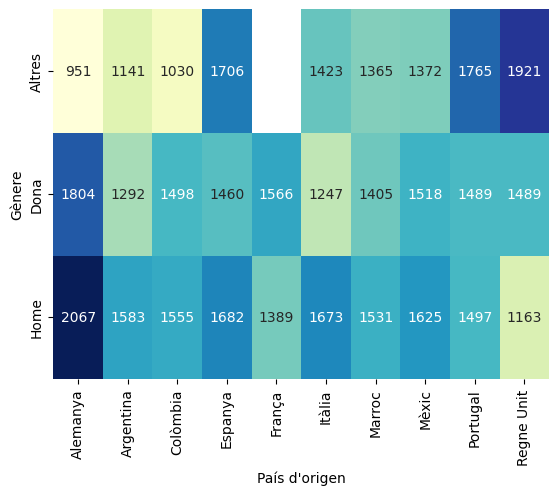

In [39]:
sns.heatmap(df_genero_pais, cmap="YlGnBu", annot=True, fmt=".0f", cbar=False)

### 6.
* Crea una nueva columna que sea la fecha de nacimiento en formato Datetime a partir de las columnas día, mes y año. Utilizando esta columna crea una función que dada una fecha, te calcule la edad actual a día de hoy.

> pd.to_datetime - convierte los valores en objetos de tipo fecha que permite realizar los cálculos temporales

> Creé la columna 'Data de naixement' como datetime a partir de las columnas Día, Mes y Año
> Para que pd.to_datetime reconozca correctamente, los nombres de las columnas deben ser 'year', 'month' y 'day' (format='%Y-%m-%d')
> En este caso no renombré las columnas, así que primero convertí los valores a texto y los concatené en formato 'DD-MM-YYYY'
> Esto permite mantener la columna como datetime para futuros cálculos y análisis

> Alternativamente,se podría usar df.assign(year=..., month=..., day=...) para crear temporalmente columnas con los nombres que pandas espera, y luego pasarlas a pd.to_datetime
> Opté por la concatenación en texto porque es más directa y clara

In [40]:
df_ordenado['Data de naixement'] = pd.to_datetime(
    df_ordenado['Any'].astype(str) + '-' + #antes de concatenar se convierte en string
    df_ordenado['Mes'].astype(str) + '-' +
    df_ordenado['Dia'].astype(str),
    format='%Y-%m-%d')

df_ordenado

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional,Nom Complet,Nascut/da a Espanya,Data de naixement
DNI,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951.0,No,Grup A,Mia Schneider Fischer,No,1976-10-22
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1769.0,Sí,Grup B,Laura Schneider Fischer,No,1958-02-02
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2013.0,No,Grup B,Lea Schneider Schneider,No,2005-10-23
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1557.0,Sí,Grup B,Mia Fischer,No,1950-08-11
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2754.0,Sí,Grup D,Jonas Schneider,No,1985-11-22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2033.0,No,Grup B,Emily Taylor Jones,No,1958-03-28
57441590Y,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1130.0,Sí,Grup A,George Brown Jones,No,1979-12-27
58204038A,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1023.0,No,Grup A,Olivia Brown Brown,No,1952-08-28


* Utiliza la función que acabas de crear para generar una columna nueva en DataFrame con la edad actual.

> dt.date.today() - devuelve la fecha actual sin hora

> Primero calculamos la diferencia de años: hoy.year-fecha_nacimiento.year

> Para realizar el cálculo más preciso, es necesario comprobar si la persoa ya ha cumplido años en el año actual: lo que está entre paréntesis si el día y el mes de nacimiento es mayor - este año no ha cumplido los años, entonces "True" que equivale "1", por tanto si la persona no ha cumplido los años se resta 1 y si es False no se resta nada. 

> Se genera la columna "edat actual" aplicando la función creada

In [41]:
def edad_actual (fecha_nacimiento):
    hoy = dt.date.today()
    edad = hoy.year - fecha_nacimiento.year - ((hoy.month, hoy.day) < (fecha_nacimiento.month, fecha_nacimiento.day))
    return edad

df_ordenado['Edat actual'] = df_ordenado['Data de naixement'].apply(edad_actual)

df_ordenado

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional,Nom Complet,Nascut/da a Espanya,Data de naixement,Edat actual
DNI,,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951.0,No,Grup A,Mia Schneider Fischer,No,1976-10-22,49
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1769.0,Sí,Grup B,Laura Schneider Fischer,No,1958-02-02,67
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2013.0,No,Grup B,Lea Schneider Schneider,No,2005-10-23,20
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1557.0,Sí,Grup B,Mia Fischer,No,1950-08-11,75
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2754.0,Sí,Grup D,Jonas Schneider,No,1985-11-22,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2033.0,No,Grup B,Emily Taylor Jones,No,1958-03-28,67
57441590Y,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1130.0,Sí,Grup A,George Brown Jones,No,1979-12-27,46
58204038A,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1023.0,No,Grup A,Olivia Brown Brown,No,1952-08-28,73


## Nivel 2

### 1.
* Utilizando el siguiente DataFrame, adjunta la columna "Increment" al dataframe del nivel anterior.

*df_increment = pd.DataFrame({"Grup":["Grup A","Grup B","Grup C", "Grup D" ] , "Increment": ["5%","3,5%","2%","8%"]})*


> reset_index() convierte el índice actual (DNI) en una columna normal, es esencial para poder hacer el merge correctamente

> inplace=True modifica el df original

> pd.merge() - une dos df, similar a un JOIN en SQL

> left_on - columna del df principal usada como clave

> right_on - columna del df auxiliar usada como clave

> how ='left' - se conservan todas las filas del df principal, aunque no haya coincidencia en el auxiliar, similar al SQL


In [42]:
df_increment = pd.DataFrame({"Grup":["Grup A","Grup B","Grup C", "Grup D" ] , "Increment": ["5%","3,5%","2%","8%"]})

df_ordenado.reset_index(inplace=True)  # convierte el índice DNI en columna

df_ordenado = pd.merge(df_ordenado,df_increment, left_on='Grup Professional',right_on='Grup',how='left').set_index('DNI') #DNI vuelve a ser índice

df_ordenado=df_ordenado.drop(columns='Grup') # Elimino la columna duplicada que ya ha cumplido su función

df_ordenado

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional,Nom Complet,Nascut/da a Espanya,Data de naixement,Edat actual,Increment
DNI,,,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951.0,No,Grup A,Mia Schneider Fischer,No,1976-10-22,49,5%
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1769.0,Sí,Grup B,Laura Schneider Fischer,No,1958-02-02,67,"3,5%"
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2013.0,No,Grup B,Lea Schneider Schneider,No,2005-10-23,20,"3,5%"
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1557.0,Sí,Grup B,Mia Fischer,No,1950-08-11,75,"3,5%"
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2754.0,Sí,Grup D,Jonas Schneider,No,1985-11-22,40,8%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2033.0,No,Grup B,Emily Taylor Jones,No,1958-03-28,67,"3,5%"
57441590Y,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1130.0,Sí,Grup A,George Brown Jones,No,1979-12-27,46,5%
58204038A,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1023.0,No,Grup A,Olivia Brown Brown,No,1952-08-28,73,5%


* Actualiza la columna salario en función de los porcentajes que se adjuntan. No modifiques manualmente los incrementos, escribe código Python para realizar las conversiones necesarias.

> La columna Increment es de tipo texto (str), contiene símbolo de % y usa coma como separador decimal por tanto no puede utilizarse directamente en operaciones matemáticas

> Los incrementos salariales están expresados como texto en formato porcentaje. Para solucionarlo se crea una columna auxiliar numérica y se divide entre 100

> Posteriormente, el salario se actualiza aplicando un factor multiplicativo (1 + incremento), ya que los porcentajes no se suman directamente al salario

> El salario final se redondea a dos decimales para representar correctamente los céntimos



In [43]:
# Convierto el incremento (str) a número (float) creando la colummna auxiliar
df_ordenado['Increment_numero'] = (
    df_ordenado['Increment']
    .str.replace('%', '', regex=False) # elimina el símbolo %
    .str.replace(',', '.', regex=False) # sustituye la coma decimal por punto para que se interpreta como el número
    .astype(float)/100) # convierte el texto en número decimal y el porcentaje a su equivalente numérico

df_ordenado['Salari mensual'] = (df_ordenado['Salari mensual'] * (1 + df_ordenado['Increment_numero'])).round(2) # Actualizo el salario según el incremento y redondeo

df_ordenado=df_ordenado.drop(columns='Increment_numero') # Elimino la columna auxiliar

df_ordenado

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional,Nom Complet,Nascut/da a Espanya,Data de naixement,Edat actual,Increment
DNI,,,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,998.55,No,Grup A,Mia Schneider Fischer,No,1976-10-22,49,5%
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1830.92,Sí,Grup B,Laura Schneider Fischer,No,1958-02-02,67,"3,5%"
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2083.46,No,Grup B,Lea Schneider Schneider,No,2005-10-23,20,"3,5%"
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1611.50,Sí,Grup B,Mia Fischer,No,1950-08-11,75,"3,5%"
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2974.32,Sí,Grup D,Jonas Schneider,No,1985-11-22,40,8%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2104.15,No,Grup B,Emily Taylor Jones,No,1958-03-28,67,"3,5%"
57441590Y,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1186.50,Sí,Grup A,George Brown Jones,No,1979-12-27,46,5%
58204038A,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1074.15,No,Grup A,Olivia Brown Brown,No,1952-08-28,73,5%


### 2.

Utilizando un bucle, exporta en 4 archivos (formato .xlsx o .csv) los datos de cada Grupo Profesional.

Por ejemplo: "datos_GrupA.xlsx" , "datos_GrupB.xlsx" ...


> .unique() - devuelve todos los valores distintos de la columna evitando duplicados

> index=False evita que el índice del df se exporte como una columna adicional en el Excel, ya que no es información relevante 


In [44]:
def grupo_export():
    """
    Exporta archivos Excel por cada 'Grup Professional'.
    Filtra filas del DataFrame según el grupo y guarda cada grupo en un archivo independiente.
    """
    for grupo in df_ordenado['Grup Professional'].unique():
        df_grupo = df_ordenado[df_ordenado['Grup Professional'] == grupo] # se aplica el filtro: solo las filas cuyo grupo profesional coincide con el valor actual del bucle
        df_grupo.to_excel(f'{grupo}.xlsx', index=False) # un excel por cada grupo con su respectivo nombre que se genera dinámicamente
grupo_export()

Exporta un 5º DataFrame en formato .xlsx o .csv que contenga cuántos trabajadores hay por cada Grupo Profesional, cuál es su sueldo medio y cuál es su edad media.

> groupby - agrupa las filas, cada grupo se trata de manera independiente 

> agg(...) - permite aplicar distintas funciones a distintas columnas

In [45]:
df_5 = df_ordenado.groupby('Grup Professional').agg( #crea 3 columnas
    Trabajadores=('Nom Complet', 'count'),
    Sueldo_medio=('Salari mensual', 'mean'),
    Edad_media=('Edat actual', 'mean')).round(2)

df_5.to_excel("resumen_grupos.xlsx")  # exporta a Excel

display(df_5)

,Trabajadores,Sueldo_medio,Edad_media
Grup Professional,,,
Grup A,490,1213.32,48.98
Grup B,318,1724.55,47.74
Grup C,137,2289.19,50.86
Grup D,55,3100.82,44.85


## Nivel 3

### 1.

Crea una función que tome un dataframe como parámetro de entrada.

La función debe crear (y exportar) un gráfico automáticamente para cada columna del dataframe. Por ejemplo:

* un histograma/boxplot si la variable es numérica
* unas barras de los valores más frecuentes si es categórica
* unas barras de los años más frecuentes si el dato está en formato fecha.
La idea es crear una función que funcione por cualquier dataframe, no sólo con lo que hemos trabajado hasta ahora.

Muestra el resultado de la función en alguno de los datasets de ejemplo que contiene el paquete seaborn. Por ejemplo, iris , penguins o titanic .

Ten en consideración que en el siguiente sprint trabajarás exclusivamente con gráficos. El objetivo de este ejercicio no es crear gráficos muy elaborados, sino resolver una necesidad de forma rápida y automática.

> En los datasets de ejemplo utilizados no siempre existían columnas de tipo datetime o categorical explícitas. Aun así, la función graficos_automaticos está diseñada para manejar cualquier df y crear automáticamente gráficos según el tipo de cada columna. Para columnas de tipo desconocido o no contempladas, la función simplemente las omite e informa de ello, asegurando que no se produzcan errores durante la ejecución.

> df.items() - devuelve pares nombre de columna - su contenido

> exist_ok=True - evita los errores si la carpeta ya existe

In [46]:
def graficos_automaticos(df, carpeta="graficos"):
    """
    Crea y guarda automáticamente un gráfico por cada columna del DataFrame según su tipo:
    
    - Numéricas: histograma y boxplot
    - Categóricas (object): barras de frecuencia
    - Fechas (datetime): barras por valor temporal

        Guarda cada gráfico como PNG.
    
    Parámetro:
    -----------
    df : DataFrame con los datos a graficar
    carpeta: el nombre de la carpeta donde se guardan todos los gráficos
    """
    os.makedirs(carpeta, exist_ok=True) #asegura de que existe una carpeta para guardar los gráficos

    for nombre, serie in df.items(): #recorre todas las columnas 
        datos = serie.dropna() # elimina los valores faltantes (para evitar errores y los gráficos vacíos)
        if datos.empty:
            continue # si tras la limpieza no ha quedado nada - omitir esta columna
    # elimina los valores faltantes 

        # Numéricas
        if is_numeric_dtype(datos) and datos.dtype !="bool": # revisa si los datos son númericos (int, float etc.) y excluye los booleanos que técnicamente son númericos, pero es mejor tratarlos como categóricos
            # Histograma
            plt.figure()
            datos.plot(kind="hist")
            plt.title(f"Histograma - {nombre}")
            plt.savefig(f"{carpeta}/{nombre}_hist.png")
            plt.close()

            # Boxplot
            plt.figure()
            datos.plot(kind="box")
            plt.title(f"Boxplot - {nombre}")
            plt.savefig(f"{carpeta}/{nombre}_box.png")
            plt.close()           

        # Fechas
        elif is_datetime64_any_dtype(datos):
            conteo = datos.value_counts().sort_index() # cuenta cuantas veces aparece cada valor y ordena por el valor, no por la frecuencia 
            plt.figure()
            conteo.plot(kind="bar") # grafica las frecuencias x-índice, y-valores
            plt.title(f"Frecuencia - {nombre}")
            plt.savefig(f"{carpeta}/{nombre}_fecha.png")
            plt.close()

        # Categóricas (texto)
        elif datos.dtype == "object" or is_categorical_dtype(datos) or datos.dtype == "bool": # incluye strings, categorias y booleanos 
            conteo = datos.value_counts()
            plt.figure()
            conteo.plot(kind="bar")
            plt.title(f"Frecuencia - {nombre}")
            plt.savefig(f"{carpeta}/{nombre}_cat.png")
            plt.close()

        else:
            print(f"Columna '{nombre}' no reconocida para graficar")
    print(f"Gráficos generados y guardados en PNG en la carpeta")

df = sns.load_dataset("titanic")
graficos_automaticos(df)

C:\Users\Tatiana\AppData\Local\Temp\ipykernel_21152\3662946402.py:50: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif datos.dtype == "object" or is_categorical_dtype(datos) or datos.dtype == "bool": # incluye strings, categorias y booleanos
C:\Users\Tatiana\AppData\Local\Temp\ipykernel_21152\3662946402.py:50: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif datos.dtype == "object" or is_categorical_dtype(datos) or datos.dtype == "bool": # incluye strings, categorias y booleanos
C:\Users\Tatiana\AppData\Local\Temp\ipykernel_21152\3662946402.py:50: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif datos.dtype == "object" or is_categorical_dtype(datos) or datos.dtype == "bool": #

Gráficos generados y guardados en PNG en la carpeta


### 2.

Carga el archivo matriz_distancies.xlsx en pandas, de modo que los nombres de filas y los nombres de columnas sean los de las ciudades.

> index_col=0 - para que la primera columna del Excel (nombres de las ciudades) sea el índice del df, de modo que filas y columnas representen las mismas ciudades

In [47]:
df_matriz_distancias = pd.read_excel('matriu_distancies.xlsx', index_col=0)

df_matriz_distancias

,Barcelona,Valencia,Sevilla,Zaragoza,Málaga,Murcia,Palma,Las Palmas de Gran Canaria,Bilbao,Alicante,Córdoba,Valladolid,Vigo,Gijón,Hospitalet de Llobregat
Barcelona,NaN,303.0,831.0,256.0,770.0,471.0,206.0,2175.0,469.0,407.0,711.0,576.0,908.0,686.0,7.0
Valencia,303.0,NaN,541.0,246.0,468.0,177.0,260.0,1874.0,473.0,125.0,421.0,441.0,766.0,632.0,297.0
Sevilla,831.0,541.0,NaN,646.0,158.0,433.0,791.0,1355.0,703.0,495.0,121.0,486.0,588.0,685.0,824.0
Zaragoza,256.0,246.0,646.0,NaN,628.0,408.0,377.0,2001.0,246.0,368.0,535.0,320.0,652.0,444.0,250.0
Málaga,770.0,468.0,158.0,628.0,NaN,323.0,695.0,1406.0,739.0,391.0,133.0,549.0,716.0,766.0,763.0
Murcia,471.0,177.0,433.0,408.0,323.0,NaN,372.0,1723.0,606.0,69.0,320.0,510.0,800.0,726.0,465.0
Palma,206.0,260.0,791.0,377.0,695.0,372.0,NaN,2093.0,621.0,303.0,671.0,664.0,1000.0,820.0,204.0
Las Palmas de Gran Canaria,2175.0,1874.0,1355.0,2001.0,1406.0,1723.0,2093.0,NaN,2022.0,1792.0,1470.0,1790.0,1682.0,1925.0,2168.0
Bilbao,469.0,473.0,703.0,246.0,739.0,606.0,621.0,2022.0,NaN,583.0,618.0,232.0,486.0,223.0,465.0
Alicante,407.0,125.0,495.0,368.0,391.0,69.0,303.0,1792.0,583.0,NaN,379.0,515.0,821.0,722.0,401.0


Borra "Las Palmas de Gran Canaria" y "Palma" para que podamos realizar el trayecto en coche.


> Al tratarse de una matriz simétrica (misma ciudad en filas y columnas), es necesario eliminar las ciudades tanto del índice como de las columnas para mantener la coherencia de los datos

In [48]:
df_matriz=df_matriz_distancias.drop(index='Palma', columns='Palma')
df_matriz=df_matriz.drop(index='Las Palmas de Gran Canaria', columns='Las Palmas de Gran Canaria')

df_matriz

,Barcelona,Valencia,Sevilla,Zaragoza,Málaga,Murcia,Bilbao,Alicante,Córdoba,Valladolid,Vigo,Gijón,Hospitalet de Llobregat
Barcelona,NaN,303.0,831.0,256.0,770.0,471.0,469.0,407.0,711.0,576.0,908.0,686.0,7.0
Valencia,303.0,NaN,541.0,246.0,468.0,177.0,473.0,125.0,421.0,441.0,766.0,632.0,297.0
Sevilla,831.0,541.0,NaN,646.0,158.0,433.0,703.0,495.0,121.0,486.0,588.0,685.0,824.0
Zaragoza,256.0,246.0,646.0,NaN,628.0,408.0,246.0,368.0,535.0,320.0,652.0,444.0,250.0
Málaga,770.0,468.0,158.0,628.0,NaN,323.0,739.0,391.0,133.0,549.0,716.0,766.0,763.0
Murcia,471.0,177.0,433.0,408.0,323.0,NaN,606.0,69.0,320.0,510.0,800.0,726.0,465.0
Bilbao,469.0,473.0,703.0,246.0,739.0,606.0,NaN,583.0,618.0,232.0,486.0,223.0,465.0
Alicante,407.0,125.0,495.0,368.0,391.0,69.0,583.0,NaN,379.0,515.0,821.0,722.0,401.0
Córdoba,711.0,421.0,121.0,535.0,133.0,320.0,618.0,379.0,NaN,419.0,589.0,634.0,704.0
Valladolid,576.0,441.0,486.0,320.0,549.0,510.0,232.0,515.0,419.0,NaN,337.0,224.0,570.0


Nos interesa visitar todas las principales ciudades de España recorriendo la mínima distancia posible.

No hace falta que lo hagas de forma óptima, nos interesa que desarrolles una solución razonable utilizando las herramientas que tienes actualmente.

Por ejemplo, una aproximación sencilla (no óptima) sería yendo siempre a la ciudad más cercana que no hayamos visitado todavía

Haz una función que dada la matriz de distancias y la ciudad de origen, haga una propuesta de ruta que sea lo más corta posible que puedas, devolviendo una lista con el orden de visita. Da también la distancia total recorrida.

In [49]:
def recorrido(df, ciudad_inicio):
    """
    Calcula una ruta aproximada visitando todas las ciudades de la matriz siguiendo la lógica de ciudad más cercana no visitada.

    Parámetros:
    df : Matriz de distancias.
    ciudad_origen : Ciudad desde la que se empieza el recorrido. (str)

    Retorna:
    ciudades_visitadas : Lista con el orden de ciudades visitadas.
    tramos : Diccionario con cada tramo recorrido y su distancia.
    distancia_total : Suma de todas las distancias de los tramos recorridos. (float)
    """

    ciudades_visitadas = [ciudad_inicio]  # lista "vacía" de ciudades visitadas, desde el principio almaceno la ciudad de origen 
    tramos = {}                            # diccionario vacío para guardar los tramos
    ciudad_actual = ciudad_inicio          # ciudad desde la cual se inicia el recorrido

    while len(ciudades_visitadas) < len(df): # Repetir hasta que todas las ciudades hayan sido visitadas
        fila = df.loc[ciudad_actual]      # fila de distancias de la ciudad actual

        distancia_min = None
        ciudad_siguiente = None

        # Busco la ciudad más cercana que no haya sido visitada
        for ciudad, distancia in fila.items():
            if ciudad not in ciudades_visitadas:
                if distancia_min is None or distancia < distancia_min:
                    distancia_min = distancia
                    ciudad_siguiente = ciudad

        # Guardo el tramo encontrado
        tramo = f"{ciudad_actual}-{ciudad_siguiente}"
        tramos[tramo] = distancia_min

        # Actualizo la lista de ciudades visitadas
        ciudades_visitadas.append(ciudad_siguiente)
        ciudad_actual = ciudad_siguiente  # actualizo la ciudad del inicio para la siguiente vuelta

    # Calculo la distancia total a partir del diccionario de tramos
    distancia_total = sum(tramos.values())

    return ciudades_visitadas, tramos, distancia_total

ciudad_inicio = 'Alicante'
ciudades, tramos, total = recorrido(df_matriz, ciudad_inicio)

print(f"Recorrido empezando desde {ciudad_inicio}\n")
print(f"Distancia total: {total} km\n")
print("Recorrido paso a paso:")
for tramo, distancia in tramos.items():
    print(f"{tramo} → {distancia} km")

Recorrido empezando desde Alicante

Distancia total: 3134.0 km

Recorrido paso a paso:
Alicante-Murcia → 69.0 km
Murcia-Valencia → 177.0 km
Valencia-Zaragoza → 246.0 km
Zaragoza-Bilbao → 246.0 km
Bilbao-Gijón → 223.0 km
Gijón-Valladolid → 224.0 km
Valladolid-Vigo → 337.0 km
Vigo-Sevilla → 588.0 km
Sevilla-Córdoba → 121.0 km
Córdoba-Málaga → 133.0 km
Málaga-Hospitalet de Llobregat → 763.0 km
Hospitalet de Llobregat-Barcelona → 7.0 km


(EXTRA) Desde qué ciudad la ruta sería más corta con el algoritmo planteado

> Este resultado no garantiza la ruta óptima global debido al algoritmo utilizado, aún así permite comparar distintos puntos de partida y elegir el más eficiente dentro de esta aproximación

In [50]:
def mejor_ruta(df):
    """
    Prueba el algoritmo de recorrido empezando desde cada ciudad de la matriz y devuelve la ciudad de origen que produce la menor distancia total, junto con dicha distancia y los tramos recorridos
    """
    mejor_ciudad_origen = None # almacenará la mejor ciudad de inicio encontrada
    mejor_distancia = None # almacenará la menor distancia total
    mejor_tramos = None # almacenará los tramos correspondientes a esa mejor ruta

    for ciudad in df.index: # se recorren todas las ciudades posibles como punto de partida
        ciudades, tramos, distancia_total = recorrido (df, ciudad) # se ejecuta el algoritmo de recorrido desde la ciudad actual

        if mejor_distancia is None or distancia_total < mejor_distancia: # compara con la mejor distancia encontrada hasta el momento
            mejor_distancia = distancia_total
            mejor_ciudad_origen = ciudad
            mejor_tramos = tramos 

    return mejor_ciudad_origen, mejor_distancia, mejor_tramos # devuelve la mejor ciudad de inicio, la distancia total y el recorrido asociado
mejor_ciudad, mejor_distancia, mejor_tramos = mejor_ruta(df_matriz)

print (f'La mejor ciudad inicial es {mejor_ciudad}\n')
print(f"Distancia total: {mejor_distancia} km\n")
print("Recorrido paso a paso:")
for tramo, distancia in mejor_tramos.items():
    print(f"{tramo} → {distancia} km")

La mejor ciudad inicial es Barcelona

Distancia total: 2778.0 km

Recorrido paso a paso:
Barcelona-Hospitalet de Llobregat → 7.0 km
Hospitalet de Llobregat-Zaragoza → 250.0 km
Zaragoza-Valencia → 246.0 km
Valencia-Alicante → 125.0 km
Alicante-Murcia → 69.0 km
Murcia-Córdoba → 320.0 km
Córdoba-Sevilla → 121.0 km
Sevilla-Málaga → 158.0 km
Málaga-Valladolid → 549.0 km
Valladolid-Gijón → 224.0 km
Gijón-Bilbao → 223.0 km
Bilbao-Vigo → 486.0 km
